In [1]:
#importing required packages

import matplotlib.pyplot as plt #for plotting 
import matplotlib as mpl
import pandas as pd             #for analyzing data
import numpy as np              #for numpy mean & accuracy
import datetime as dt           #for datetime objects
import numpy.ma as ma           #for masked array
import xarray as xr

import xesmf as xe              #for regriding
from netCDF4 import Dataset,date2num, num2date, date2index  # http://code.google.com/p/netcdf4-python/
import netCDF4 as nc
import cartopy.crs as ccrs     #for the map process
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
import matplotlib.ticker as mticker
import daylength as dlen   #calculate daylength


#for plotting in notebook
%matplotlib inline



In [2]:
#Read and process pollen emission file
filepath = '/Users/yingxz/Desktop/Research/Pollen_WRF/'

#choose the year of the data you want
start_year = 2025
end_year = 2025
time = str(start_year)+'-'+str(end_year)
#filename = 'pollen_emissions_'+time+'_25km_speciated-calc_taxon.nc'  # Your filename
filename = 'pollen_obs_2025_ef_T_PFT.nc'  # Your filename
nc_f = filepath + filename
#pollen = Dataset(nc_f, 'r')  # Dataset is the class behavior to open the file
                             # and create an instance of the ncCDF4 class


#print(pollen)

In [3]:
#read data with xarray
pollen = xr.open_dataset(nc_f)
pollen

<xarray.Dataset>
Dimensions:  (iy: 144, jx: 243, lev: 1, time: 365, spec: 5, year: 1)
Coordinates:
  * lev      (lev) float32 1.0
  * time     (time) datetime64[ns] 2025-01-02 2025-01-03 ... 2026-01-01
  * spec     (spec) float32 1.0 2.0 3.0 4.0 5.0
  * year     (year) float32 1.0
Dimensions without coordinates: iy, jx
Data variables:
    lon      (iy, jx) float32 ...
    lat      (iy, jx) float32 ...
    POLLEN   (spec, time, lev, iy, jx) float32 ...
    clm_lc   (iy, jx) float64 ...
    sDOY     (spec, year, iy, jx) float32 ...
    eDOY     (spec, year, iy, jx) float32 ...
    dur      (spec, year, iy, jx) float32 ...
    ef       (spec, year, iy, jx) float32 ...

In [4]:
#Read in the domain file from WRF_Chem
filepath_W = '/Users/yingxz/Desktop/Research/Pollen_WRF/'

filename_W = 'rapchem_latlong.nc'  # Your filename
nc_W = filepath_W + filename_W
WRF = xr.open_dataset(nc_W)
#WRF = Dataset(nc_W, 'r')
#WRF
height = WRF.variables['XLAND']
#height = WRF['XLAND'][:]
print(height)
#WRF

<xarray.Variable (Time: 1, south_north: 834, west_east: 953)>
[794802 values with dtype=float32]
Attributes:
    FieldType:    104
    MemoryOrder:  XY 
    description:  LAND MASK (1 FOR LAND, 2 FOR WATER)
    units:        
    stagger:      


In [5]:
#print(WRF)
lat_W =WRF.variables['XLAT'][0,:,:]
lon_W = WRF.variables['XLONG'][0,:,:]
#lat_W 
#lon_W
niy_W = np.shape(lat_W)[0]
njx_W = np.shape(lat_W)[1]

print(lon_W)

<xarray.Variable (south_north: 834, west_east: 953)>
[794802 values with dtype=float32]
Attributes:
    FieldType:    104
    MemoryOrder:  XY 
    description:  LONGITUDE, WEST IS NEGATIVE
    units:        degree_east
    stagger:      


In [6]:
#get the variables from pollen emission dataset
time = pollen.variables['time']
lat = pollen.variables['lat']
lon = pollen.variables['lon']

# get length of axis data
ntime = len(time)
niy = np.shape(lat)[0]
njx = np.shape(lat)[1]


flux = pollen['POLLEN'][:]
print(flux)
#flux = np.where(flux > 0., flux, 0.)
#print(flux)

<xarray.DataArray 'POLLEN' (spec: 5, time: 365, lev: 1, iy: 144, jx: 243)>
[63860400 values with dtype=float32]
Coordinates:
  * lev      (lev) float32 1.0
  * time     (time) datetime64[ns] 2025-01-02 2025-01-03 ... 2026-01-01
  * spec     (spec) float32 1.0 2.0 3.0 4.0 5.0
Dimensions without coordinates: iy, jx
Attributes:
    long_name:  pollen emission potential (flux)
    units:      grains m-2 day-1


In [7]:
#assign datetime to the variable
start_date =  dt.datetime(start_year, 1, 1)
end_date = start_date + dt.timedelta(days = ntime)
print("start_date:",start_date)
print("end_date:",end_date)

time =[start_date + dt.timedelta(days=x) for x in range(0, (end_date-start_date).days)]


flux['time'] = time
flux.time

start_date: 2025-01-01 00:00:00
end_date: 2026-01-01 00:00:00


<xarray.DataArray 'time' (time: 365)>
array(['2025-01-01T00:00:00.000000000', '2025-01-02T00:00:00.000000000',
       '2025-01-03T00:00:00.000000000', ..., '2025-12-29T00:00:00.000000000',
       '2025-12-30T00:00:00.000000000', '2025-12-31T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 2025-01-01 2025-01-02 ... 2025-12-31

In [8]:
#select the time you want to analyze, the time doesn't include the end_DOY
start_DOY = dt.datetime(2025, 2, 1)
end_DOY = dt.datetime(2025, 3, 1)

delta = end_DOY - start_DOY
print(delta.days)


28


In [9]:
#select the specific date of pollen emission
flux_sel = flux.sel(time=np.arange(start_DOY, end_DOY, np.timedelta64(1, 'D'), dtype='datetime64[D]'))
time1 = np.array(time)
time_sel = time1[(time1 >= start_DOY) & (time1 < end_DOY)]
print(time_sel)

#change all of the negative values into 
print(flux_sel)
for i in range(5):
    flux_sel[i,0,0,:,:] = np.where(flux_sel[i,0,0,:,:]>=0, flux_sel[i,0,0,:,:], np.nan)

#np.isnan(flux_sel)
#flux_sel[0,0,0,:,:]

[datetime.datetime(2025, 2, 1, 0, 0) datetime.datetime(2025, 2, 2, 0, 0)
 datetime.datetime(2025, 2, 3, 0, 0) datetime.datetime(2025, 2, 4, 0, 0)
 datetime.datetime(2025, 2, 5, 0, 0) datetime.datetime(2025, 2, 6, 0, 0)
 datetime.datetime(2025, 2, 7, 0, 0) datetime.datetime(2025, 2, 8, 0, 0)
 datetime.datetime(2025, 2, 9, 0, 0) datetime.datetime(2025, 2, 10, 0, 0)
 datetime.datetime(2025, 2, 11, 0, 0) datetime.datetime(2025, 2, 12, 0, 0)
 datetime.datetime(2025, 2, 13, 0, 0) datetime.datetime(2025, 2, 14, 0, 0)
 datetime.datetime(2025, 2, 15, 0, 0) datetime.datetime(2025, 2, 16, 0, 0)
 datetime.datetime(2025, 2, 17, 0, 0) datetime.datetime(2025, 2, 18, 0, 0)
 datetime.datetime(2025, 2, 19, 0, 0) datetime.datetime(2025, 2, 20, 0, 0)
 datetime.datetime(2025, 2, 21, 0, 0) datetime.datetime(2025, 2, 22, 0, 0)
 datetime.datetime(2025, 2, 23, 0, 0) datetime.datetime(2025, 2, 24, 0, 0)
 datetime.datetime(2025, 2, 25, 0, 0) datetime.datetime(2025, 2, 26, 0, 0)
 datetime.datetime(2025, 2, 27, 0,

In [10]:
#total pollen emission of all species for original pollen data
flux_sel_all = np.nansum(flux_sel, axis=0)
#print(flux_sel_all0.shape)
#average of all the selected day
#flux_sel_all = np.mean(flux_sel_all0, axis=0)
print(flux_sel_all.shape)

flux_sel_all = np.where(flux_sel_all >= 0., flux_sel_all, -9999)

flux_sel

(28, 1, 144, 243)


<xarray.DataArray 'POLLEN' (spec: 5, time: 28, lev: 1, iy: 144, jx: 243)>
array([[[[[   nan, ...,     0.],
          ...,
          [   nan, ...,     0.]]],


        ...,


        [[[-9999., ...,     0.],
          ...,
          [-9999., ...,     0.]]]],



       ...,



       [[[[   nan, ...,     0.],
          ...,
          [   nan, ...,     0.]]],


        ...,


        [[[-9999., ...,     0.],
          ...,
          [-9999., ...,     0.]]]]], dtype=float32)
Coordinates:
  * lev      (lev) float32 1.0
  * time     (time) datetime64[ns] 2025-02-01 2025-02-02 ... 2025-02-28
  * spec     (spec) float32 1.0 2.0 3.0 4.0 5.0
Dimensions without coordinates: iy, jx
Attributes:
    long_name:  pollen emission potential (flux)
    units:      grains m-2 day-1

In [11]:
#regrid pollen dile into WRF_Chem domain
ds = flux_sel
#ds_out = height
ds=ds.assign_coords({"lon": lon})
ds=ds.assign_coords({"lat": lat})
ds

#regrid options: When regridding from low-resolution to high-resolution, 
#bilinear and patch will produce smooth results, while conservative and nearest_s2d will preserve the original coarse grid structure 
#(although the data is now defined on a finer grid.).
#When regridding from high-resolution to low-resolution, all methods except nearest_d2s produce similar results here. But that’s largely because the input data is smooth. For real-world data, 
#it is generally recommended to use conservative for upscaling, because it takes average over small source grid boxes, while bilinear and nearest_s2d effectively throw away most of source grid boxes.
ds_out = xr.Dataset(data_vars=dict(height=(["time","x", "y"], height),),coords=dict(lon=(["x", "y"], lon_W),lat=(["x", "y"], lat_W),),)
ds_out
regridder = xe.Regridder(ds, ds_out, 'bilinear')
regridder.clean_weight_file()
regridder

Create weight file: bilinear_144x243_834x953.nc
Remove file bilinear_144x243_834x953.nc


xESMF Regridder 
Regridding algorithm:       bilinear 
Weight filename:            bilinear_144x243_834x953.nc 
Reuse pre-computed weights? False 
Input grid shape:           (144, 243) 
Output grid shape:          (834, 953) 
Output grid dimension name: ('x', 'y') 
Periodic in longitude?      False

In [12]:
flux_out = regridder(ds)
flux_out
#ds_out
flux_out

/Users/yingxz/opt/anaconda3/envs/xesmf_env/lib/python3.7/site-packages/xesmf/frontend.py:421: FutureWarning: ``output_sizes`` should be given in the ``dask_gufunc_kwargs`` parameter. It will be removed as direct parameter in a future version.
  keep_attrs=keep_attrs


<xarray.DataArray 'POLLEN' (spec: 5, time: 28, lev: 1, x: 834, y: 953)>
array([[[[[0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          ...,
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.]]],


        [[[0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          ...,
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.]]],


        [[[0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
...
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.]]],


        [[[0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          ...,
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.]]],


        [[[0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          ...,
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.],
          [0., 0., 0., ..., 0., 0., 0.]]]]])
Coordinates:
  * lev      (lev) float32 1.0
  * time     (time) datetime64[ns] 2025-02-01 2025-02-02 ... 2025-02-28
  * spec     (spec) float32 1.0 2.0 3.0 4.0 5.0
    lon      (x, y) float32 -139.1 -139.0 -139.0 -138.9 ... 22.65 22.65 22.66
    lat      (x, y) float32 -10.59 -10.54 -10.48 -10.43 ... 46.75 46.67 46.59
Dimensions without coordinates: x, y
Attributes:
    regrid_method:  bilinear

In [13]:
#total pollen emission of 15 species for regridded data
flux_out_all = np.sum(flux_out, axis=0)
flux_out_all

#flux_out_all = np.where(flux_out_all >= 0, flux_out_all, 0)

#flux_out_all

<xarray.DataArray 'POLLEN' (time: 28, lev: 1, x: 834, y: 953)>
array([[[[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]]],


       [[[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]]],


       [[[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
...
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]]],


       [[[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]]],


       [[[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]]]])
Coordinates:
  * lev      (lev) float32 1.0
  * time     (time) datetime64[ns] 2025-02-01 2025-02-02 ... 2025-02-28
    lon      (x, y) float32 -139.1 -139.0 -139.0 -138.9 ... 22.65 22.65 22.66
    lat      (x, y) float32 -10.59 -10.54 -10.48 -10.43 ... 46.75 46.67 46.59
Dimensions without coordinates: x, y

In [14]:
help (dlen)

#time disaggregation (based on the calculated day length)
#calculate how many hours during the daytime

day_of_year = []
for date in time_sel:
    print(date)
    day_of_year.append((date - dt.datetime(date.year, 1, 1)).days + 1)
print(day_of_year)

dayhr = np.full_like(flux_out_all, np.nan, dtype=np.double)
dayhr0 = np.full_like(flux_out_all[0,0,:,:], np.nan, dtype=np.double)

dayhr0

#for i in range(delta.days):
for j in range (niy_W):
    for k in range(njx_W):
        dayhr0[j,k]=dlen.daylength(day_of_year[15], lat_W[j,k])
        
#for i in range(delta.days):
#    dayhr[i,0,:,:] = dayhr0[:,:]
#for i in range(delta.days):
#    for j in range (niy_W):
#        for k in range(njx_W):
#            dayhr[i,0,j,k]=dlen.daylength(day_of_year[i], lat_W[j,k])
            
#print(dayhr)

Help on module daylength:

NAME
    daylength

FUNCTIONS
    daylength(dayOfYear, lat)
        Computes the length of the day (the time between sunrise and
        sunset) given the day of the year and latitude of the location.
        Function uses the Brock model for the computations.
        For more information see, for example,
        Forsythe et al., "A model comparison for daylength as a
        function of latitude and day of year", Ecological Modelling,
        1995.
        Parameters
        ----------
        dayOfYear : int
            The day of the year. 1 corresponds to 1st of January
            and 365 to 31st December (on a non-leap year).
        lat : float
            Latitude of the location in degrees. Positive values
            for north and negative for south.
        Returns
        -------
        d : float
            Daylength in hours.

FILE
    /Users/yingxz/Desktop/Research/Pollen_WRF/daylength.py


2025-02-01 00:00:00
2025-02-02 00:00:00
2025-02-03 0

In [15]:
for i in range(delta.days):
    dayhr[i,0,:,:] = dayhr0[:,:]

In [16]:
dayhr

array([[[[12.33748024, 12.33572585, 12.33397525, ..., 12.33397512,
          12.33572591, 12.33747914],
         [12.334634  , 12.33287654, 12.33112301, ..., 12.33112284,
          12.33287665, 12.33463292],
         [12.33178876, 12.33002835, 12.32827167, ..., 12.32827159,
          12.33002838, 12.33178769],
         ...,
         [10.07309463, 10.06776093, 10.06241182, ..., 10.06241182,
          10.06776093, 10.07309108],
         [10.07257952, 10.06725683, 10.06191964, ..., 10.06191919,
          10.06725728, 10.07257596],
         [10.07208261, 10.06677184, 10.06144633, ..., 10.0614461 ,
          10.06677184, 10.07207906]]],


       [[[12.33748024, 12.33572585, 12.33397525, ..., 12.33397512,
          12.33572591, 12.33747914],
         [12.334634  , 12.33287654, 12.33112301, ..., 12.33112284,
          12.33287665, 12.33463292],
         [12.33178876, 12.33002835, 12.32827167, ..., 12.32827159,
          12.33002838, 12.33178769],
         ...,
         [10.07309463, 10.067760

In [17]:
#devide the total pollen emission by the daylength -> hourly pollen emission data
#assume pollen emission only happens during the daytime

#print(dayhr)
print(dayhr.shape)

flux_hr0 = np.divide(flux_out_all,dayhr)
flux_hr0.shape


(28, 1, 834, 953)


/Users/yingxz/opt/anaconda3/envs/xesmf_env/lib/python3.7/site-packages/xarray/core/computation.py:733: RuntimeWarning: invalid value encountered in true_divide
  result_data = func(*input_data)


(28, 1, 834, 953)

In [18]:
#get the average
#flux_hr = np.mean(flux_hr0, axis=0)
#flux_hr.shape

flux_hr = np.where(flux_hr0 > 0., flux_hr0, 0.)
flux_hr.shape
#flux_sel_all = np.where(flux_sel_all > 0., flux_sel_all, -9999)

(28, 1, 834, 953)

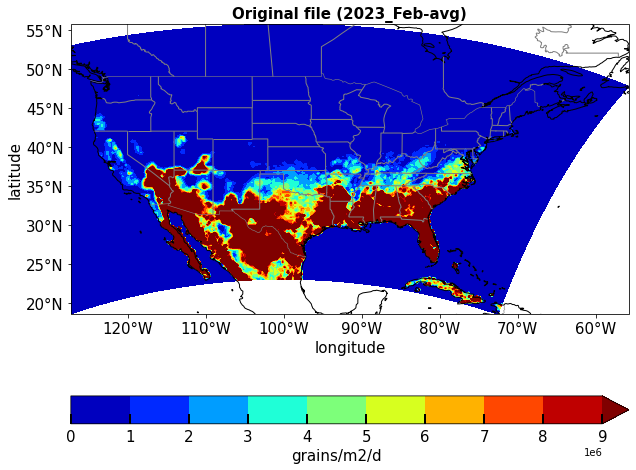

In [19]:
#Plot the original pollen emission
colormap = "jet"
lev = range(0,int(1e7),int(1e6))
#-- create figure and axes object
#fig, ax = plt.subplots(figsize=(12,8))
plt.figure(3, figsize=(10,10), facecolor='white')
#-- choose map projection
ax = plt.axes(projection=ccrs.PlateCarree())



#-- add title
ax.set_title('Original file (2023_Feb-avg)', fontsize=15, fontweight='bold')

ax.set_xlabel('longitude', fontsize = 15)
ax.set_ylabel('latitude', fontsize = 15)
#-- add tickmarks
ax.set_xticks(range(-140,-50,10), crs=ccrs.PlateCarree())
ax.set_yticks(range(10,60,5), crs=ccrs.PlateCarree())
ax.xaxis.set_major_formatter(LongitudeFormatter())
ax.yaxis.set_major_formatter(LatitudeFormatter())

#ax.set(xlim=(lon(0,0),lon(niy-1,njx-1)), ylim=(lat(0,0),lat(niy-1,njx-1)))
#-- create contour line plot
cnplot = ax.contourf(lon, lat, flux_sel_all[0,0,:,:], cmap=colormap, levels=lev, transform=ccrs.PlateCarree(), extend = 'max')
#-- add coastlines, country border lines, and grid lines
ax.coastlines()

#-- create states outlines
states_provinces = cfeature.NaturalEarthFeature(category='cultural',
                            name='admin_1_states_provinces_lines',
                            scale='50m', facecolor='none')
ax.add_feature(cfeature.BORDERS, linewidth=0.6, edgecolor='gray')
ax.add_feature(states_provinces, edgecolor='gray')
 
#ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', xlocs=range(-180,180,30), ylocs=range(-90,90,30))

#ax.set_ylim([-5, 130])
ax.set_xlim(lon[0,0],lon[niy-1,njx-1])
#ax.set_ylim(lat[0,0],lat[niy-1,njx-1])
#plt.imshow(extent=[lon(0,0),lon(niy-1,njx-1), lat(0,0),lat(niy-1,njx-1)], alpha=0.5)

ax.tick_params('y', labelsize = 15)
ax.tick_params('x', labelsize = 15)
#-- add colorbar
cbar = plt.colorbar(cnplot, orientation='horizontal')
cbar.ax.tick_params(direction='in',length=10,width=2,labelsize=15,pad=5)
#cbar.ax.xaxis.set_major_locator(mticker.FixedLocator(lev))
#cbar = plt.colorbar(cnplot, location='bottom', pad=0.08, shrink=0.55)
cbar.set_label('grains/m2/d', fontsize = 15)

#-- save graphic output to PNG file
#plt.savefig('Pollen_original'+str(dt.datetime(2013, 4, 1))+'.png', bbox_inches='tight', dpi=100)



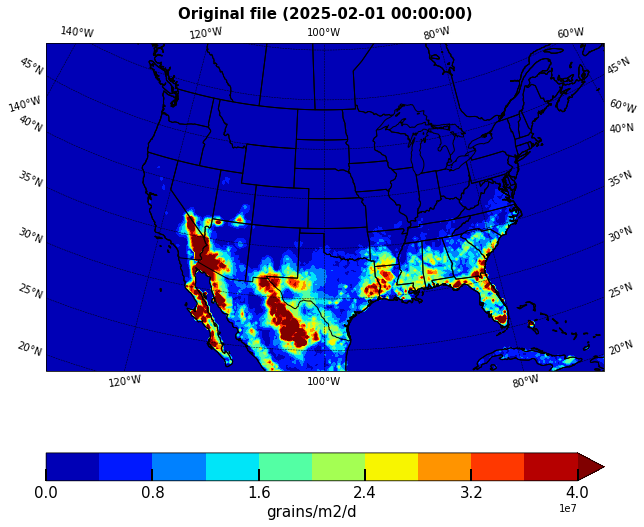

In [20]:
#Plot the original pollen emission
colormap = "jet"
lev = range(0,int(4.4e7),int(4e6))
#-- create figure and axes object
#fig, ax = plt.subplots(figsize=(12,8))
plt.figure(3, figsize=(10,10), facecolor='white')

#-- choose map projection

mapcrs = ccrs.LambertConformal(
    central_longitude=-100, central_latitude=35, standard_parallels=(30, 60))
#-- choose map projection
ax = plt.axes(projection=mapcrs)

#-- add title
ax.set_title('Original file ('+ str(dt.datetime(2025,2, 1)) + ')', fontsize=15, fontweight='bold')

#ax.set_xlabel('longitude', fontsize = 15)
#ax.set_ylabel('latitude', fontsize = 15)
#-- add tickmarks
#ax.set_xticks(range(-140,-50,10), crs=ccrs.PlateCarree())
#ax.set_yticks(range(20,60,5), crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False,
              color='k', linestyle='dashed', linewidth=0.5)

gl.top_labels=True
gl.bottom_labels=True
gl.left_labels=True
gl.right_labels=True
#ax.xaxis.set_major_formatter(LongitudeFormatter())
#ax.yaxis.set_major_formatter(LatitudeFormatter())

#ax.set(xlim=(lon(0,0),lon(niy-1,njx-1)), ylim=(lat(0,0),lat(niy-1,njx-1)))
#-- create contour line plot
cnplot = ax.contourf(lon, lat, flux_sel_all[0,0,:,:], cmap=colormap, levels=lev, transform=ccrs.PlateCarree(), extend='max')
#cnplot = (flux_sel_all[0,0,:,:]).plot.contourf(ax=ax, transform=ccrs.PlateCarree(), cmap=colormap, levels=lev, extend='max')
#-- add coastlines, country border lines, and grid lines
ax.coastlines()

#-- create states outlines
#states_provinces = cfeature.NaturalEarthFeature(category='cultural',
#                            name='admin_1_states_provinces_lines',
#                            scale='50m', facecolor='none')
#ax.add_feature(cfeature.BORDERS, linewidth=0.6, edgecolor='gray')
#ax.add_feature(states_provinces, edgecolor='gray')
ax.add_feature(cfeature.COASTLINE.with_scale('50m'))
ax.add_feature(cfeature.STATES.with_scale('50m'))
#ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', xlocs=range(-180,180,30), ylocs=range(-90,90,30))

#ax.set_xticks([-140, -100, -40], crs=ccrs.PlateCarree())

#ax.set_ylim([-5, 130])
#ax.set_xlim(lon[0,0],lon[niy-1,njx-1])
#ax.set_ylim(lat[0,0],lat[niy-1,njx-1])
#plt.imshow(extent=[lon(0,0),lon(niy-1,njx-1), lat(0,0),lat(niy-1,njx-1)], alpha=0.5)

ax.tick_params('y', labelsize = 15)
ax.tick_params('x', labelsize = 15)
#-- add colorbar
cbar = plt.colorbar(cnplot, orientation='horizontal')
cbar.ax.tick_params(direction='in',length=12,width=2,labelsize=15,pad=5)
#cbar.ax.xaxis.set_major_locator(mticker.FixedLocator(lev))
#cbar = plt.colorbar(cnplot, location='bottom', pad=0.08, shrink=0.55)
cbar.set_label('grains/m2/d', fontsize = 15)

#-- save graphic output to PNG file
plt.savefig('Pollen_original'+str(dt.datetime(2025, 2, 1))+'.png', bbox_inches='tight', dpi=100)




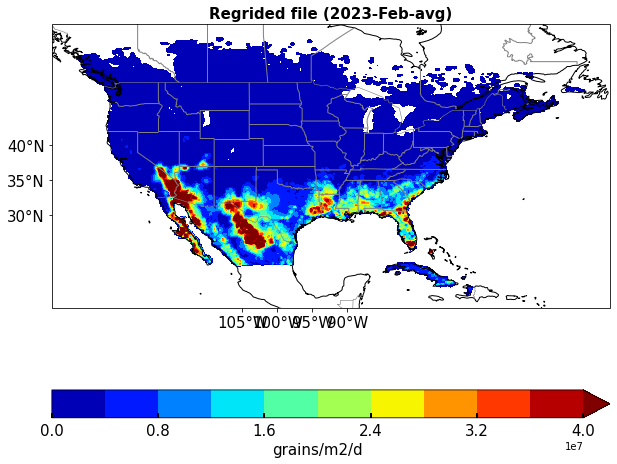

In [21]:
#Plot the regridded pollen emission
colormap = "jet"

#-- create figure and axes object
plt.figure(3, figsize=(10,10), facecolor='white')

#-- choose map projection
ax = plt.axes(projection=ccrs.PlateCarree())


#ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', xlocs=range(-180,180,30), ylocs=range(-90,90,30))

#-- add title
ax.set_title('Regrided file (2023-Feb-avg)', fontsize=15, fontweight='bold')

#ax.set_xlim([-125,-70])
#ax.set_ylim([20,55])
#-- add tickmarks
ax.set_xticks([-105, -100, -95, -90], crs=ccrs.PlateCarree())
ax.set_yticks([30, 35, 40], crs=ccrs.PlateCarree())
ax.xaxis.set_major_formatter(LongitudeFormatter())
ax.yaxis.set_major_formatter(LatitudeFormatter())
#-- create contour line plot
cnplot = ax.contourf(lon_W, lat_W, flux_out_all[0,0,:,:], cmap=colormap, levels=range(1,int(4.4e7),int(4e6)), transform=ccrs.PlateCarree(),extend = 'max')

#-- add coastlines, country border lines, and grid lines
ax.coastlines()

#-- create states outlines
states_provinces = cfeature.NaturalEarthFeature(category='cultural',
                            name='admin_1_states_provinces_lines',
                            scale='50m', facecolor='none')
ax.add_feature(cfeature.BORDERS, linewidth=0.6, edgecolor='gray')
ax.add_feature(states_provinces, edgecolor='gray')
 
ax.tick_params('y', labelsize = 15)
ax.tick_params('x', labelsize = 15)
#-- add colorbar
cbar = plt.colorbar(cnplot, orientation='horizontal')
cbar.ax.tick_params(direction='in',length=5,width=2,labelsize=15,pad=5)

cbar.set_label('grains/m2/d',fontsize = 15)

#-- save graphic output to PNG file
plt.savefig('plot_pollen_hr_regridded'+str(dt.datetime(2023, 2, 1))+'_.png', bbox_inches='tight', dpi=100)


In [22]:
flux_out_all

<xarray.DataArray 'POLLEN' (time: 28, lev: 1, x: 834, y: 953)>
array([[[[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]]],


       [[[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]]],


       [[[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
...
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]]],


       [[[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]]],


       [[[0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         ...,
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.],
         [0., 0., 0., ..., 0., 0., 0.]]]])
Coordinates:
  * lev      (lev) float32 1.0
  * time     (time) datetime64[ns] 2025-02-01 2025-02-02 ... 2025-02-28
    lon      (x, y) float32 -139.1 -139.0 -139.0 -138.9 ... 22.65 22.65 22.66
    lat      (x, y) float32 -10.59 -10.54 -10.48 -10.43 ... 46.75 46.67 46.59
Dimensions without coordinates: x, y

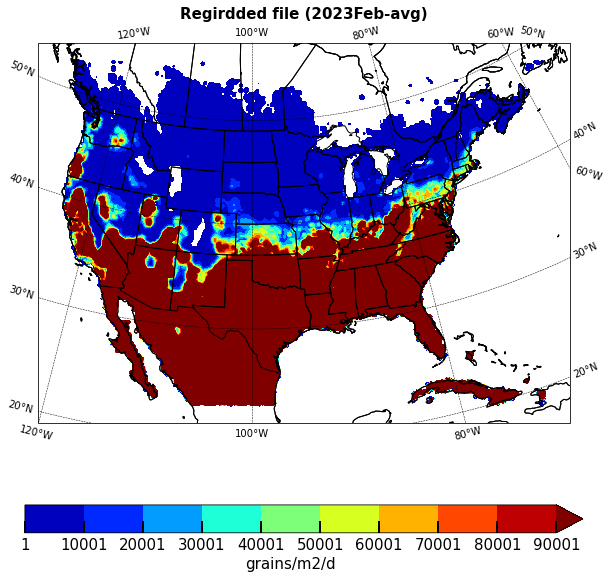

In [23]:
#Plot the original pollen emission
colormap = "jet"
lev = range(1,int(1e5),int(1e4))
#-- create figure and axes object
#fig, ax = plt.subplots(figsize=(12,8))
plt.figure(3, figsize=(10,10), facecolor='white')

#-- choose map projection

mapcrs = ccrs.LambertConformal(
    central_longitude=-100, central_latitude=35, standard_parallels=(30, 60))
#-- choose map projection
ax = plt.axes(projection=mapcrs)

#ax.set_xlim([-125,-70])
#ax.set_ylim([20,55])
#-- add title
#ax.set_title('Regirdded file ('+ str(dt.datetime(2016, 5, 2)) + ')', fontsize=15, fontweight='bold')

ax.set_title('Regirdded file (2023Feb-avg)', fontsize=15, fontweight='bold')
#ax.set_xlabel('longitude', fontsize = 15)
#ax.set_ylabel('latitude', fontsize = 15)
#-- add tickmarks
#ax.set_xticks(range(-140,-50,10), crs=ccrs.PlateCarree())
#ax.set_yticks(range(20,60,5), crs=ccrs.PlateCarree())
gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False,
              color='k', linestyle='dashed', linewidth=0.5)

gl.top_labels=True
gl.bottom_labels=True
gl.left_labels=True
gl.right_labels=True
#ax.xaxis.set_major_formatter(LongitudeFormatter())
#ax.yaxis.set_major_formatter(LatitudeFormatter())

#ax.set(xlim=(lon(0,0),lon(niy-1,njx-1)), ylim=(lat(0,0),lat(niy-1,njx-1)))
#-- create contour line plot
cnplot = ax.contourf(lon_W, lat_W, flux_hr[0,0,:,:], cmap=colormap, levels=lev, transform=ccrs.PlateCarree(), extend='max')
#cnplot = (flux_sel_all[0,0,:,:]).plot.contourf(ax=ax, transform=ccrs.PlateCarree(), cmap=colormap, levels=lev, extend='max')
#-- add coastlines, country border lines, and grid lines
ax.coastlines()

#-- create states outlines
#states_provinces = cfeature.NaturalEarthFeature(category='cultural',
#                            name='admin_1_states_provinces_lines',
#                            scale='50m', facecolor='none')
#ax.add_feature(cfeature.BORDERS, linewidth=0.6, edgecolor='gray')
#ax.add_feature(states_provinces, edgecolor='gray')
ax.add_feature(cfeature.COASTLINE.with_scale('50m'))
ax.add_feature(cfeature.STATES.with_scale('50m'))
#ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', xlocs=range(-180,180,30), ylocs=range(-90,90,30))

#ax.set_xticks([-140, -100, -40], crs=ccrs.PlateCarree())

#ax.set_ylim([-5, 130])
#ax.set_xlim(lon[0,0],lon[niy-1,njx-1])
#ax.set_ylim(lat[0,0],lat[niy-1,njx-1])
#plt.imshow(extent=[lon(0,0),lon(niy-1,njx-1), lat(0,0),lat(niy-1,njx-1)], alpha=0.5)

ax.tick_params('y', labelsize = 15)
ax.tick_params('x', labelsize = 15)
#-- add colorbar
cbar = plt.colorbar(cnplot, orientation='horizontal')
cbar.ax.tick_params(direction='in',length=12,width=2,labelsize=15,pad=5)
#cbar.ax.xaxis.set_major_locator(mticker.FixedLocator(lev))
#cbar = plt.colorbar(cnplot, location='bottom', pad=0.08, shrink=0.55)
cbar.set_label('grains/m2/d', fontsize = 15)

#-- save graphic output to PNG file
plt.savefig('Pollen_regrid'+str(dt.datetime(2023, 2, 1))+'.png', bbox_inches='tight', dpi=100)


In [24]:

#write output pollen file
for i in range(delta.days):
    print(i)
    f = open("wrfchemP_d01_"+str(start_DOY+dt.timedelta(days=i))+"_hr(cal).txt", "w")
    for row in flux_hr[i,:,:,:]:
        np.savetxt(f, row, delimiter='\n')
        #print(row[0,:])
    f.close()
    #print(flux_hr[i,:,:,:])



0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27


In [25]:
#check the pollen file we just wrote
#file = open("wrfchemP_d01_"+str(start_DOY+dt.timedelta(days=0))+"_hr(cal).txt", "r")
#file = open("wrfchemP_d01_"+str(start_DOY)+"-"+str(end_DOY)+"avg"+"_hr(cal).txt", "r")
#content = file.read()
#content
content = np.loadtxt("wrfchemP_d01_"+str(start_DOY+dt.timedelta(days=0))+"_hr(cal).txt").reshape(834,953)

content
#print("\nContent in file2.txt:\n", content)

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [26]:

#file.close()

In [27]:
#content0 = np.full_like(flux_out_all[0,0,:,:], np.nan, dtype=np.double)
#content0[:,:] = content[:,:]
#content0

#flux_test = xr.Dataset({'flux_test':(['x','y'], content)})
#lattitude = xr.Dataset({'lattitude':(['x','y'], np.cos(content))})
#longitude = xr.Dataset({'longitude':(['x','y'], np.sin(content))})

#ds = xr.merge([flux_test, lattitude, longitude])

#ds.set_coords(['lattitude','longitude'])
#flux_test

#content.assign_coords(lat_W=("lat", lat))

da = xr.DataArray(
        data=content,
        dims=["x", "y"],
        coords=dict(
        lon=(["x", "y"], lon_W),
        lat=(["x", "y"], lat_W),
        ),
)
da

<xarray.DataArray (x: 834, y: 953)>
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])
Coordinates:
    lon      (x, y) float32 -139.1 -139.0 -139.0 -138.9 ... 22.65 22.65 22.66
    lat      (x, y) float32 -10.59 -10.54 -10.48 -10.43 ... 46.75 46.67 46.59
Dimensions without coordinates: x, y

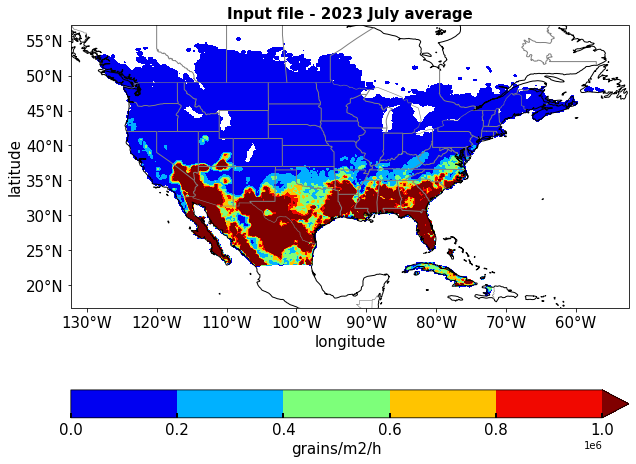

In [28]:
#Plot the original pollen emission
colormap = "jet"
lev = range(1,int(1.2e6),int(2e5))
#-- create figure and axes object
plt.figure(3, figsize=(10,10), facecolor='white')

#-- choose map projection
ax = plt.axes(projection=ccrs.PlateCarree())


 
#ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', xlocs=range(-180,180,30), ylocs=range(-90,90,30))

#-- add title
ax.set_title('Input file - 2023 July average', fontsize=15, fontweight='bold')

ax.set_xlabel('longitude', fontsize = 15)
ax.set_ylabel('latitude', fontsize = 15)
#-- add tickmarks
ax.set_xticks(range(-140,-50,10), crs=ccrs.PlateCarree())
ax.set_yticks(range(20,60,5), crs=ccrs.PlateCarree())
ax.xaxis.set_major_formatter(LongitudeFormatter())
ax.yaxis.set_major_formatter(LatitudeFormatter())

#ax.set(xlim=(lon(0,0),lon(niy-1,njx-1)), ylim=(lat(0,0),lat(niy-1,njx-1)))
#-- create contour line plot
#cnplot = ax.contourf(lon_W, lat_W, da, cmap=colormap, levels=lev, transform=ccrs.PlateCarree())
cnplot = ax.contourf(lon_W, lat_W, da, cmap=colormap, levels=lev, transform=ccrs.PlateCarree(),extend = 'max')
#-- add coastlines, country border lines, and grid lines
ax.coastlines()

#-- create states outlines
states_provinces = cfeature.NaturalEarthFeature(category='cultural',
                            name='admin_1_states_provinces_lines',
                            scale='50m', facecolor='none')
ax.add_feature(cfeature.BORDERS, linewidth=0.6, edgecolor='gray')
ax.add_feature(states_provinces, edgecolor='gray')

ax.tick_params('y', labelsize = 15)
ax.tick_params('x', labelsize = 15)
#-- add colorbar
cbar = plt.colorbar(cnplot, orientation='horizontal')
cbar.ax.tick_params(direction='in',length=5,width=2,labelsize=15,pad=5)

cbar.set_label('grains/m2/h',fontsize = 15)
#-- save graphic output to PNG file
#plt.savefig('Pollen_original'+str(dt.datetime(2013, 4, 13))+'.png', bbox_inches='tight', dpi=100)

Write in the NetCDF file

In [29]:
try: ncfile.close()  # just to be safe, make sure dataset is not already open.
except: pass
ncfile = Dataset('Pollen_Feb_2023_daily.nc',mode='w',format='NETCDF4_CLASSIC') 
print(ncfile)

<class 'netCDF4._netCDF4.Dataset'>
root group (NETCDF4_CLASSIC data model, file format HDF5):
    dimensions(sizes): 
    variables(dimensions): 
    groups: 



In [30]:
lat_dim = ncfile.createDimension('south_north', 834)     # latitude axis
lon_dim = ncfile.createDimension('west_east', 953)    # longitude axis
time_dim = ncfile.createDimension('time', None) # unlimited axis (can be appended to).
for dim in ncfile.dimensions.items():
    print(dim)


('south_north', <class 'netCDF4._netCDF4.Dimension'>: name = 'south_north', size = 834
)
('west_east', <class 'netCDF4._netCDF4.Dimension'>: name = 'west_east', size = 953
)
('time', <class 'netCDF4._netCDF4.Dimension'> (unlimited): name = 'time', size = 0
)


In [31]:
ncfile.title='hourly pollen emission for each day in Feb 2023'
print(ncfile.title)


hourly pollen emission for each day in Feb 2023


/Users/yingxz/opt/anaconda3/envs/xesmf_env/lib/python3.7/site-packages/ipykernel_launcher.py:2: DeprecationWarning: tostring() is deprecated. Use tobytes() instead.
  


In [32]:
ncfile.subtitle="Created by PECM 2.0"
print(ncfile.subtitle)
print(ncfile)

Created by PECM 2.0
<class 'netCDF4._netCDF4.Dataset'>
root group (NETCDF4_CLASSIC data model, file format HDF5):
    title: hourly pollen emission for each day in Feb 2023
    subtitle: Created by PECM 2.0
    dimensions(sizes): south_north(834), west_east(953), time(0)
    variables(dimensions): 
    groups: 



/Users/yingxz/opt/anaconda3/envs/xesmf_env/lib/python3.7/site-packages/ipykernel_launcher.py:2: DeprecationWarning: tostring() is deprecated. Use tobytes() instead.
  
/Users/yingxz/opt/anaconda3/envs/xesmf_env/lib/python3.7/site-packages/ipykernel_launcher.py:3: DeprecationWarning: tostring() is deprecated. Use tobytes() instead.
  This is separate from the ipykernel package so we can avoid doing imports until


In [33]:
WRF

<xarray.Dataset>
Dimensions:  (Time: 1, south_north: 834, west_east: 953, west_east_stag: 954, south_north_stag: 835)
Coordinates:
    XLAT     (Time, south_north, west_east) float32 ...
    XLAT_U   (Time, south_north, west_east_stag) float32 ...
    XLAT_V   (Time, south_north_stag, west_east) float32 ...
    XLONG    (Time, south_north, west_east) float32 ...
    XLONG_U  (Time, south_north, west_east_stag) float32 ...
    XLONG_V  (Time, south_north_stag, west_east) float32 ...
    XTIME    (Time) datetime64[ns] ...
Dimensions without coordinates: Time, south_north, west_east, west_east_stag, south_north_stag
Data variables:
    XLAND    (Time, south_north, west_east) float32 2.0 2.0 2.0 ... 1.0 1.0 1.0
Attributes: (12/124)
    TITLE:                            OUTPUT FROM *             PROGRAM:WRF-C...
    START_DATE:                      2020-09-20_00:00:00
    SIMULATION_START_DATE:           2020-09-20_00:00:00
    WEST-EAST_GRID_DIMENSION:        954
    SOUTH-NORTH_GRID_DIMENSION:      835
    BOTTOM-TOP_GRID_DIMENSION:       51
    ...                              ...
    description:                     column wet scavening flux
    units:                           mmol or ug m^-2
    stagger:                         Z
    history:                         Mon Feb 28 18:07:23 2022: ncks -v XLAT*,...
    NCO:                             netCDF Operators version 4.9.3 (Homepage...
    history_of_appended_files:       Sat Dec 18 18:58:54 2021: Appended file ...

In [34]:
flux_hr.shape

(28, 1, 834, 953)

In [35]:
# Define two variables with the same names as dimensions,
# a conventional way to define "coordinate variables".
lat = ncfile.createVariable('XLAT', np.float32, ('time','south_north','west_east'))
lat.units = 'degrees_north'
lat.long_name = 'LATITUDE, SOUTH IS NEGATIVE'
lon = ncfile.createVariable('XLON', np.float32, ('time','south_north','west_east'))
lon.units = 'degrees_east'
lon.long_name = 'LONGITUDE, WEST IS NEGATIVE'
time = ncfile.createVariable('XTIME', np.float64, ('time',))
time.units = 'days since 2024-10-01'
time.long_name = 'time'
# Define a 3D variable to hold the data
flux = ncfile.createVariable('FLUX',np.float64,('time','south_north','west_east')) # note: unlimited dimension is leftmost
flux.units = 'grains/m2/hr' # degrees Kelvin
flux.standard_name = 'pollen emission flux' # this is a CF standard name
print(flux)

<class 'netCDF4._netCDF4.Variable'>
float64 FLUX(time, south_north, west_east)
    units: grains/m2/hr
    standard_name: pollen emission flux
unlimited dimensions: time
current shape = (0, 834, 953)
filling on, default _FillValue of 9.969209968386869e+36 used



/Users/yingxz/opt/anaconda3/envs/xesmf_env/lib/python3.7/site-packages/ipykernel_launcher.py:16: DeprecationWarning: tostring() is deprecated. Use tobytes() instead.
  app.launch_new_instance()


In [36]:
print("-- Some pre-defined attributes for variable flux:")
print("flux.dimensions:",flux.dimensions)
print("flux.shape:", flux.shape)
print("flux.dtype:", flux.dtype)
print("flux.ndim:", flux.ndim)

-- Some pre-defined attributes for variable flux:
flux.dimensions: ('time', 'south_north', 'west_east')
flux.shape: (0, 834, 953)
flux.dtype: float64
flux.ndim: 3


In [37]:
lat=lat_W
lon=lon_W
ntime = 31

flux[:,:,:] = flux_hr[:,0,:,:] # Appends data along unlimited dimension
print("-- Wrote data, temp.shape is now ", flux.shape)
# read data back from variable (by slicing it), print min and max
print("-- Min/Max values:", flux[:,:,:].min(), flux[:,:,:].max())

-- Wrote data, temp.shape is now  (28, 834, 953)


/Users/yingxz/opt/anaconda3/envs/xesmf_env/lib/python3.7/site-packages/ipykernel_launcher.py:8: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  


-- Min/Max values: 0.0 7675886.794698011


In [38]:
print(time)
times_arr = time[:]
print(type(times_arr),times_arr)  # dashes indicate masked values (where data has not yet been written)

<class 'netCDF4._netCDF4.Variable'>
float64 XTIME(time)
    units: days since 2024-10-01
    long_name: time
unlimited dimensions: time
current shape = (28,)
filling on, default _FillValue of 9.969209968386869e+36 used

<class 'numpy.ma.core.MaskedArray'> [-- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- -- --
 -- -- -- --]


/Users/yingxz/opt/anaconda3/envs/xesmf_env/lib/python3.7/site-packages/ipykernel_launcher.py:1: DeprecationWarning: tostring() is deprecated. Use tobytes() instead.
  """Entry point for launching an IPython kernel.
/Users/yingxz/opt/anaconda3/envs/xesmf_env/lib/python3.7/site-packages/ipykernel_launcher.py:2: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  


In [39]:
times = date2num(time_sel, time.units)
print(times, time.units) # numeric values

[123 124 125 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140
 141 142 143 144 145 146 147 148 149 150] days since 2024-10-01


/Users/yingxz/opt/anaconda3/envs/xesmf_env/lib/python3.7/site-packages/ipykernel_launcher.py:1: DeprecationWarning: tostring() is deprecated. Use tobytes() instead.
  """Entry point for launching an IPython kernel.
/Users/yingxz/opt/anaconda3/envs/xesmf_env/lib/python3.7/site-packages/ipykernel_launcher.py:2: DeprecationWarning: tostring() is deprecated. Use tobytes() instead.
  


In [40]:
time[:] = times
# read time data back, convert to datetime instances, check values.
print(time[:])
print(time.units)
print(num2date(time[:],time.units))

[123. 124. 125. 126. 127. 128. 129. 130. 131. 132. 133. 134. 135. 136.
 137. 138. 139. 140. 141. 142. 143. 144. 145. 146. 147. 148. 149. 150.]
days since 2024-10-01
[cftime.DatetimeGregorian(2025, 2, 1, 0, 0, 0, 0, has_year_zero=False)
 cftime.DatetimeGregorian(2025, 2, 2, 0, 0, 0, 0, has_year_zero=False)
 cftime.DatetimeGregorian(2025, 2, 3, 0, 0, 0, 0, has_year_zero=False)
 cftime.DatetimeGregorian(2025, 2, 4, 0, 0, 0, 0, has_year_zero=False)
 cftime.DatetimeGregorian(2025, 2, 5, 0, 0, 0, 0, has_year_zero=False)
 cftime.DatetimeGregorian(2025, 2, 6, 0, 0, 0, 0, has_year_zero=False)
 cftime.DatetimeGregorian(2025, 2, 7, 0, 0, 0, 0, has_year_zero=False)
 cftime.DatetimeGregorian(2025, 2, 8, 0, 0, 0, 0, has_year_zero=False)
 cftime.DatetimeGregorian(2025, 2, 9, 0, 0, 0, 0, has_year_zero=False)
 cftime.DatetimeGregorian(2025, 2, 10, 0, 0, 0, 0, has_year_zero=False)
 cftime.DatetimeGregorian(2025, 2, 11, 0, 0, 0, 0, has_year_zero=False)
 cftime.DatetimeGregorian(2025, 2, 12, 0, 0, 0, 0, h

/Users/yingxz/opt/anaconda3/envs/xesmf_env/lib/python3.7/site-packages/ipykernel_launcher.py:3: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  This is separate from the ipykernel package so we can avoid doing imports until
/Users/yingxz/opt/anaconda3/envs/xesmf_env/lib/python3.7/site-packages/ipykernel_launcher.py:4: DeprecationWarning: tostring() is deprecated. Use tobytes() instead.
  after removing the cwd from sys.path.
/Users/yingxz/opt/anaconda3/envs/xesmf_env/lib/python3.7/site-packages/ipykernel_launcher.py:5: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify an

In [41]:
# first print the Dataset object to see what we've got
print(ncfile)
# close the Dataset.
ncfile.close(); print('Dataset is closed!')

<class 'netCDF4._netCDF4.Dataset'>
root group (NETCDF4_CLASSIC data model, file format HDF5):
    title: hourly pollen emission for each day in Feb 2023
    subtitle: Created by PECM 2.0
    dimensions(sizes): south_north(834), west_east(953), time(28)
    variables(dimensions): float32 XLAT(time,south_north,west_east), float32 XLON(time,south_north,west_east), float64 XTIME(time), float64 FLUX(time,south_north,west_east)
    groups: 

Dataset is closed!


/Users/yingxz/opt/anaconda3/envs/xesmf_env/lib/python3.7/site-packages/ipykernel_launcher.py:2: DeprecationWarning: tostring() is deprecated. Use tobytes() instead.
  
